In [1]:
# ============================================================
# BLOCO 1 - LEITURA DA BASE E INDICADORES PRINCIPAIS
# Censo da Educação Superior 2024 - Base de IES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# Configuração visual
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid")

# Montar o Google Drive
drive.mount('/pasta raiz dos dados')
# ------------------------------------------------------------
# Leitura da base
# ------------------------------------------------------------

pasta_dados = "pasta/Dados_Colab/MINERACAO"

caminho_ies = f"{pasta_dados}/MICRODADOS_ED_SUP_IES_2024.CSV"
caminho_cursos = f"{pasta_dados}/MICRODADOS_CADASTRO_CURSOS_2024.CSV"

ies = pd.read_csv(
    caminho_ies,
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("Dimensão original da base:", ies.shape)

# ------------------------------------------------------------
# Filtro inicial
# Mantém apenas IES com docentes em exercício
# ------------------------------------------------------------

ies = ies[ies["QT_DOC_EXE"] > 0].copy()

# ------------------------------------------------------------
# Criação da variável SETOR
# TP_REDE: 1 = Pública | 2 = Privada
# ------------------------------------------------------------

ies["SETOR"] = ies["TP_REDE"].map({
    1: "Pública",
    2: "Privada"
})

ies = ies.dropna(subset=["SETOR"]).copy()

print("Dimensão após filtro:", ies.shape)

print("\nQuantidade de IES por setor:")
print(ies["SETOR"].value_counts())

# ------------------------------------------------------------
# Indicadores principais
# São usados para comparar IES de tamanhos diferentes
# ------------------------------------------------------------

ies["PERC_DOUTORES"] = (ies["QT_DOC_EX_DOUT"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_MESTRES"] = (ies["QT_DOC_EX_MEST"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_INT_DE"] = (ies["QT_DOC_EX_INT_DE"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_PARCIAL"] = (ies["QT_DOC_EX_PARC"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_HORISTA"] = (ies["QT_DOC_EX_HOR"] / ies["QT_DOC_EXE"]) * 100

# Tratamento simples
ies = ies.replace([np.inf, -np.inf], np.nan)
ies = ies.fillna(0)

# ------------------------------------------------------------
# Resumo inicial
# ------------------------------------------------------------

resumo_setor = ies.groupby("SETOR")[
    [
        "QT_DOC_EXE",
        "PERC_DOUTORES",
        "PERC_MESTRES",
        "PERC_INT_DE",
        "PERC_PARCIAL",
        "PERC_HORISTA"
    ]
].mean().round(2)

display(resumo_setor)

Mounted at /content/drive
Dimensão original da base: (2561, 84)
Dimensão após filtro: (2558, 85)

Quantidade de IES por setor:
SETOR
Privada    2241
Pública     317
Name: count, dtype: int64


,QT_DOC_EXE,PERC_DOUTORES,PERC_MESTRES,PERC_INT_DE,PERC_PARCIAL,PERC_HORISTA
SETOR,,,,,,
Privada,83.52,29.42,44.48,2.69,42.13,34.19
Pública,590.97,49.12,33.45,39.02,14.91,27.63


,Até 29,30 a 34,35 a 39,40 a 44,45 a 49,50 a 54,55 a 59,60 ou mais
SETOR,,,,,,,,
Privada,4.94,12.69,17.46,17.74,15.97,11.70,8.46,11.05
Pública,1.99,7.12,14.60,18.71,16.72,13.44,11.49,15.92


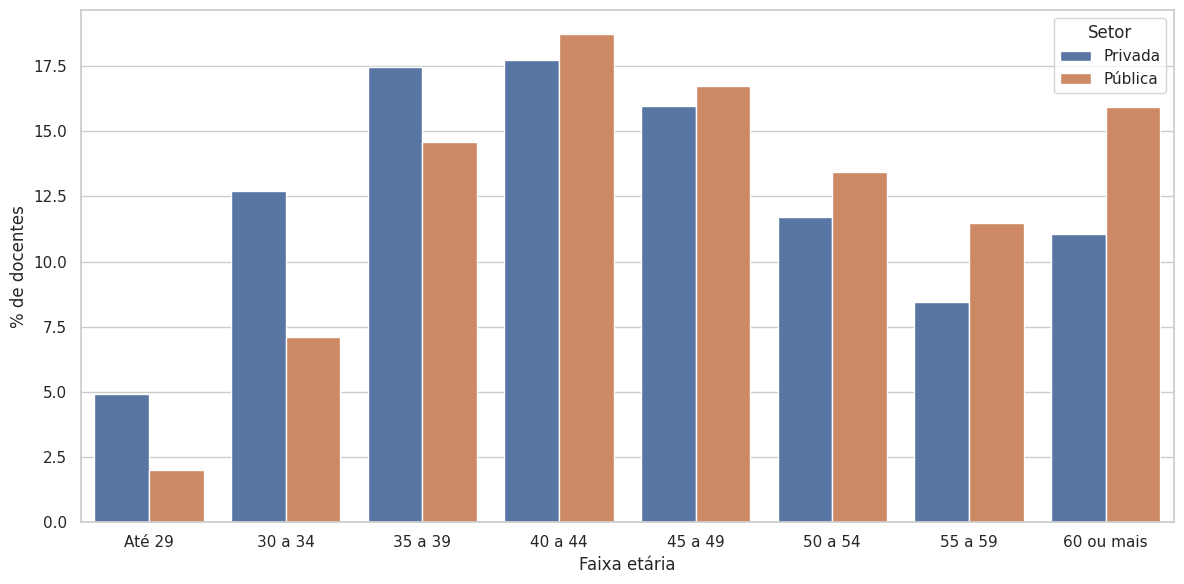

In [2]:
# ============================================================
# BLOCO 2 - GRÁFICO 1
# Distribuição etária dos docentes por setor
# ============================================================

# Colunas de faixa etária disponíveis na base
colunas_idade = [
    "QT_DOC_EX_0_29",
    "QT_DOC_EX_30_34",
    "QT_DOC_EX_35_39",
    "QT_DOC_EX_40_44",
    "QT_DOC_EX_45_49",
    "QT_DOC_EX_50_54",
    "QT_DOC_EX_55_59",
    "QT_DOC_EX_60_MAIS"
]

# Nomes que aparecerão no gráfico
nomes_faixas = [
    "Até 29",
    "30 a 34",
    "35 a 39",
    "40 a 44",
    "45 a 49",
    "50 a 54",
    "55 a 59",
    "60 ou mais"
]

# Agrupa os totais de docentes por setor
idade_setor = ies.groupby("SETOR")[colunas_idade].sum()

# Converte para percentual dentro de cada setor
idade_setor_pct = idade_setor.div(idade_setor.sum(axis=1), axis=0) * 100

# Ajusta nomes das colunas
idade_setor_pct.columns = nomes_faixas

# Transforma para formato longo, melhor para gráfico com seaborn
idade_plot = idade_setor_pct.reset_index().melt(
    id_vars="SETOR",
    var_name="Faixa etária",
    value_name="Percentual"
)

# Exibe tabela resumida
display(idade_setor_pct.round(2))

# Gráfico
plt.figure(figsize=(12, 6))

sns.barplot(
    data=idade_plot,
    x="Faixa etária",
    y="Percentual",
    hue="SETOR"
)

#plt.title("Distribuição etária dos docentes por setor - Censo da Educação Superior 2024")
plt.xlabel("Faixa etária")
plt.ylabel("% de docentes")
plt.legend(title="Setor")
plt.xticks(rotation=0)
plt.tight_layout()

# Salvar figura
plt.savefig("grafico_1_faixa_etaria_setor_2024.pdf", format="pdf", bbox_inches="tight")

plt.show()

,Graduação,Especialização,Mestrado,Doutorado
SETOR,,,,
Privada,0.04,22.04,44.33,33.59
Pública,1.11,5.80,20.66,72.44


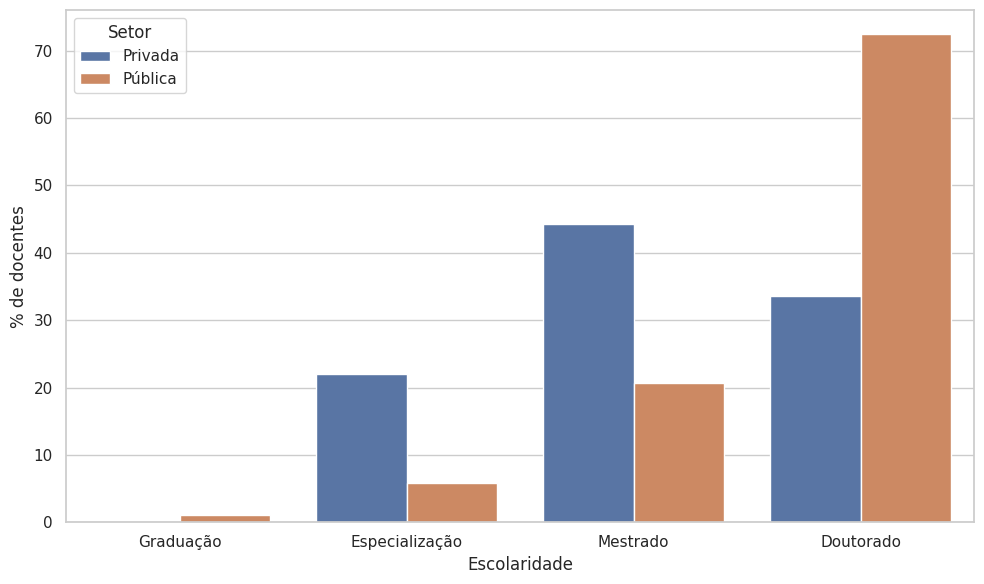

In [3]:
# ============================================================
# BLOCO 3 - GRÁFICO 2
# Escolaridade docente por setor
# ============================================================

# Colunas de escolaridade disponíveis na base
colunas_escolaridade = [
    "QT_DOC_EX_GRAD",
    "QT_DOC_EX_ESP",
    "QT_DOC_EX_MEST",
    "QT_DOC_EX_DOUT"
]

# Nomes para o gráfico
nomes_escolaridade = [
    "Graduação",
    "Especialização",
    "Mestrado",
    "Doutorado"
]

# Agrupa o total de docentes por escolaridade em cada setor
escolaridade_setor = ies.groupby("SETOR")[colunas_escolaridade].sum()

# Converte para percentual dentro de cada setor
escolaridade_setor_pct = escolaridade_setor.div(
    escolaridade_setor.sum(axis=1),
    axis=0
) * 100

# Renomeia as colunas para o gráfico
escolaridade_setor_pct.columns = nomes_escolaridade

# Transforma para formato longo
escolaridade_plot = escolaridade_setor_pct.reset_index().melt(
    id_vars="SETOR",
    var_name="Escolaridade",
    value_name="Percentual"
)

# Exibe tabela resumida
display(escolaridade_setor_pct.round(2))

# Gráfico
plt.figure(figsize=(10, 6))

sns.barplot(
    data=escolaridade_plot,
    x="Escolaridade",
    y="Percentual",
    hue="SETOR"
)

#plt.title("Escolaridade dos docentes por setor - Censo da Educação Superior 2024")
plt.xlabel("Escolaridade")
plt.ylabel("% de docentes")
plt.legend(title="Setor")
plt.tight_layout()

# Salvar figura
plt.savefig("grafico_2_escolaridade_setor_2024.pdf", format="pdf", bbox_inches="tight")

plt.show()

count   mean    std  min    25%    50%    75%    max
Titulação SETOR                                                         
Doutorado Privada  2241.0  29.42  19.78  0.0  14.81  26.79  40.00  100.0
          Pública   317.0  49.12  26.91  0.0  28.17  45.00  73.72  100.0
Mestrado  Privada  2241.0  44.48  17.36  0.0  33.33  45.83  55.74  100.0
          Pública   317.0  33.45  17.30  0.0  18.07  37.04  46.15  100.0

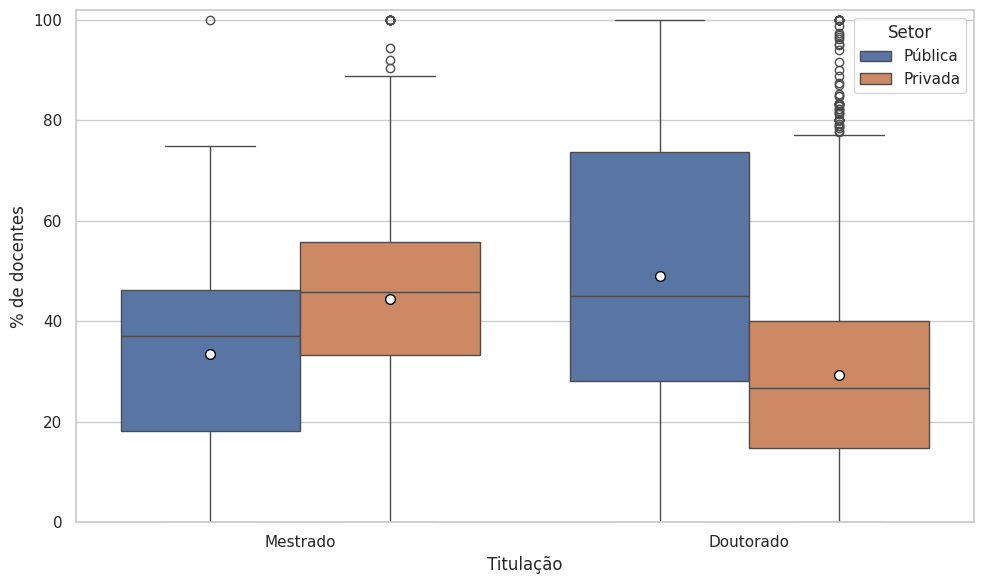

In [4]:
# ============================================================
# BLOCO 4 - GRÁFICO 3
# Boxplot do percentual de mestres e doutores por setor
# ============================================================

# ------------------------------------------------------------
# Garante que os percentuais existem
# ------------------------------------------------------------

ies["PERC_MESTRES"] = (ies["QT_DOC_EX_MEST"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_DOUTORES"] = (ies["QT_DOC_EX_DOUT"] / ies["QT_DOC_EXE"]) * 100

# Tratamento simples
ies = ies.replace([np.inf, -np.inf], np.nan)
ies["PERC_MESTRES"] = ies["PERC_MESTRES"].fillna(0)
ies["PERC_DOUTORES"] = ies["PERC_DOUTORES"].fillna(0)

# ------------------------------------------------------------
# Cria base em formato longo
# ------------------------------------------------------------

dados_titulacao = ies[["SETOR", "PERC_MESTRES", "PERC_DOUTORES"]].copy()

dados_titulacao = dados_titulacao.melt(
    id_vars="SETOR",
    value_vars=["PERC_MESTRES", "PERC_DOUTORES"],
    var_name="Titulação",
    value_name="Percentual"
)

# Renomeia para ficar legível no gráfico
dados_titulacao["Titulação"] = dados_titulacao["Titulação"].map({
    "PERC_MESTRES": "Mestrado",
    "PERC_DOUTORES": "Doutorado"
})

# ------------------------------------------------------------
# Tabela resumo
# ------------------------------------------------------------

resumo_titulacao = dados_titulacao.groupby(["Titulação", "SETOR"])["Percentual"].describe().round(2)
display(resumo_titulacao)

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=dados_titulacao,
    x="Titulação",
    y="Percentual",
    hue="SETOR",
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.xlabel("Titulação")
plt.ylabel("% de docentes")
plt.ylim(0, 102)
plt.legend(title="Setor")
plt.tight_layout()

plt.savefig("grafico_3_boxplot_mestres_doutores_setor_2024.pdf",
            format="pdf", bbox_inches="tight")

plt.show()

Correlação entre dedicação exclusiva e formação stricto sensu por setor:


,SETOR,Correlação
0,Privada,-0.0081
1,Pública,0.3859


PERC_INT_DE               PERC_STRICTO_SENSU              
               mean median    std               mean median    std
SETOR                                                             
Privada        2.69   0.00   9.16              73.89  76.92  20.66
Pública       39.02  21.38  39.58              82.58  88.12  18.66

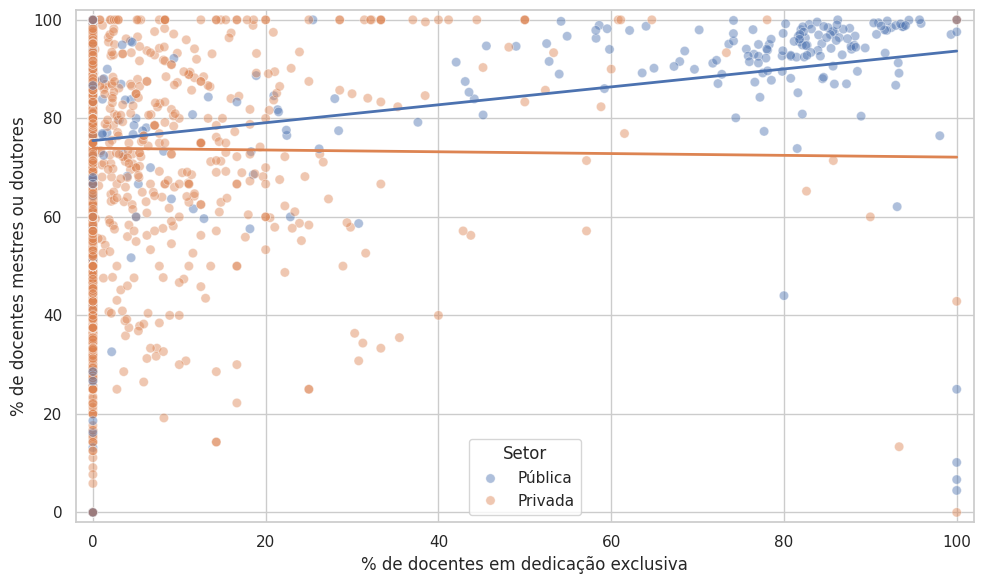

In [ ]:
# ============================================================
# BLOCO 5 - GRÁFICO 4
# Relação entre dedicação exclusiva e qualificação stricto sensu
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Garante que os percentuais existem
# ------------------------------------------------------------

ies["PERC_MESTRES"] = (ies["QT_DOC_EX_MEST"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_DOUTORES"] = (ies["QT_DOC_EX_DOUT"] / ies["QT_DOC_EXE"]) * 100
ies["PERC_STRICTO_SENSU"] = ies["PERC_MESTRES"] + ies["PERC_DOUTORES"]
ies["PERC_INT_DE"] = (ies["QT_DOC_EX_INT_DE"] / ies["QT_DOC_EXE"]) * 100

# Tratamento de valores inválidos
ies = ies.replace([np.inf, -np.inf], np.nan)

ies["PERC_MESTRES"] = ies["PERC_MESTRES"].fillna(0)
ies["PERC_DOUTORES"] = ies["PERC_DOUTORES"].fillna(0)
ies["PERC_STRICTO_SENSU"] = ies["PERC_STRICTO_SENSU"].fillna(0)
ies["PERC_INT_DE"] = ies["PERC_INT_DE"].fillna(0)

# ------------------------------------------------------------
# Base usada no gráfico
# ------------------------------------------------------------

dados_scatter = ies[
    [
        "SETOR",
        "PERC_INT_DE",
        "PERC_STRICTO_SENSU"
    ]
].copy()

dados_scatter = dados_scatter.dropna()

# ------------------------------------------------------------
# Correlação por setor sem warning
# ------------------------------------------------------------

correlacao_setor = dados_scatter.groupby("SETOR")[
    ["PERC_INT_DE", "PERC_STRICTO_SENSU"]
].corr()

correlacao_setor = correlacao_setor.loc[
    (slice(None), "PERC_INT_DE"),
    "PERC_STRICTO_SENSU"
].reset_index()

correlacao_setor = correlacao_setor.rename(columns={
    "level_0": "SETOR",
    "PERC_STRICTO_SENSU": "Correlação"
})

correlacao_setor = correlacao_setor[["SETOR", "Correlação"]].round(4)

print("Correlação entre dedicação exclusiva e formação stricto sensu por setor:")
display(correlacao_setor)

# ------------------------------------------------------------
# Tabela resumo
# ------------------------------------------------------------

resumo_scatter = dados_scatter.groupby("SETOR")[
    [
        "PERC_INT_DE",
        "PERC_STRICTO_SENSU"
    ]
].agg(["mean", "median", "std"]).round(2)

display(resumo_scatter)

# ------------------------------------------------------------
# Gráfico
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=dados_scatter,
    x="PERC_INT_DE",
    y="PERC_STRICTO_SENSU",
    hue="SETOR",
    alpha=0.45,
    s=45
)

sns.regplot(
    data=dados_scatter[dados_scatter["SETOR"] == "Pública"],
    x="PERC_INT_DE",
    y="PERC_STRICTO_SENSU",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2}
)

sns.regplot(
    data=dados_scatter[dados_scatter["SETOR"] == "Privada"],
    x="PERC_INT_DE",
    y="PERC_STRICTO_SENSU",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2}
)

plt.xlabel("% de docentes em dedicação exclusiva")
plt.ylabel("% de docentes mestres ou doutores")
plt.xlim(-2, 102)
plt.ylim(-2, 102)
plt.legend(title="Setor")
plt.tight_layout()

plt.savefig(
    "grafico_4_scatter_stricto_sensu_intde_2024.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Razão de desbalanceamento: 7.06:1  (privada:pública)
Pesos → Privada: 1.0  |  Pública: 10.59

=== RESULTADO COM THRESHOLD AJUSTADO ===
Threshold utilizado: 0.35
Acurácia: 0.9258

Matriz de confusão:
[[658  15]
 [ 42  53]]

Relatório de classificação:
              precision    recall  f1-score   support

     Privada       0.94      0.98      0.96       673
     Pública       0.78      0.56      0.65        95

    accuracy                           0.93       768
   macro avg       0.86      0.77      0.80       768
weighted avg       0.92      0.93      0.92       768



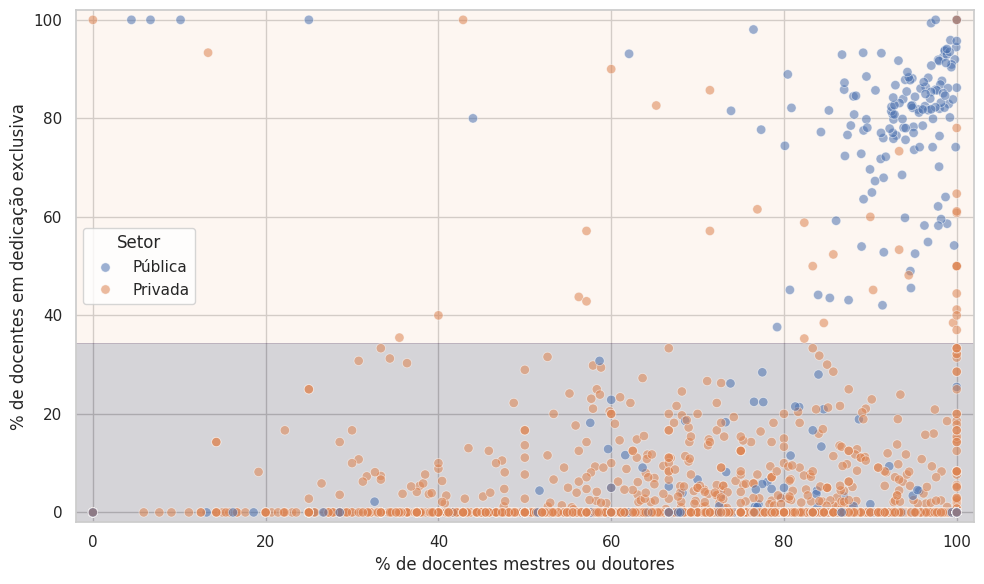

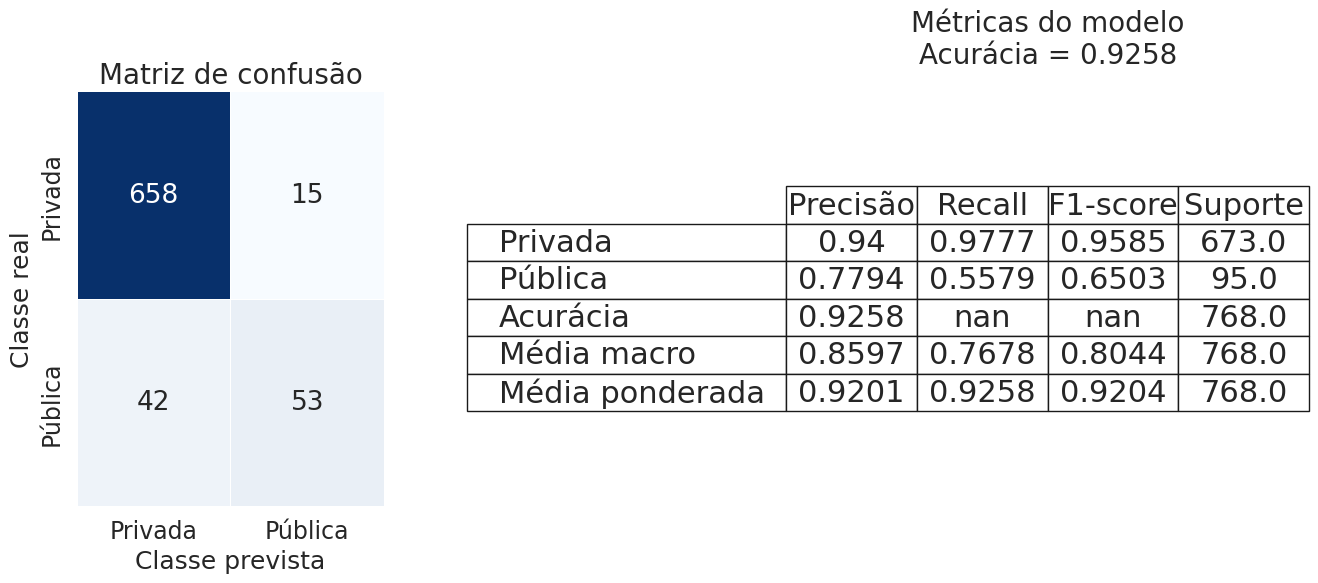

In [ ]:
# ============================================================
# BLOCO 6 - GRÁFICO 5
# SVM com class_weight customizado + threshold ajustado
# Objetivo: melhorar recall/F1 da classe "Pública" sem
#            sacrificar demais a classe "Privada"
# ============================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd

# Garante que o indicador existe
ies["PERC_STRICTO_SENSU"] = ies["PERC_MESTRES"] + ies["PERC_DOUTORES"]

# ------------------------------------------------------------
# Seleção dos atributos
# ------------------------------------------------------------

dados_svm = ies[
    [
        "PERC_STRICTO_SENSU",
        "PERC_INT_DE",
        "SETOR"
    ]
].copy()

dados_svm = dados_svm.dropna()

X = dados_svm[["PERC_STRICTO_SENSU", "PERC_INT_DE"]]

y = dados_svm["SETOR"].map({
    "Privada": 0,
    "Pública": 1
})

# ------------------------------------------------------------
# Padronização
# ------------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# Separação treino/teste
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Cálculo do desbalanceamento real
# ------------------------------------------------------------

n_privada = (y_train == 0).sum()
n_publica = (y_train == 1).sum()
ratio = n_privada / n_publica   # ~7:1 no dataset original

# Peso customizado: amplifica o peso da pública além do "balanced"
# Fator 1.5× sobre o peso natural → penaliza erros em públicas mais ainda
fator_amplificacao = 1.5
peso_publica = ratio * fator_amplificacao
peso_privada = 1.0

class_weights_custom = {0: peso_privada, 1: peso_publica}

print(f"Razão de desbalanceamento: {ratio:.2f}:1  (privada:pública)")
print(f"Pesos → Privada: {peso_privada}  |  Pública: {peso_publica:.2f}")

# ------------------------------------------------------------
# Treinamento do SVM com peso amplificado
# ------------------------------------------------------------

modelo_svm = SVC(
    kernel="linear",
    C=1.0,
    class_weight=class_weights_custom,
    probability=True     # necessário para ajuste de threshold
)

modelo_svm.fit(X_train, y_train)

# ------------------------------------------------------------
# Ajuste de threshold de decisão
# Padrão sklearn = 0.50; baixar → mais sensível à classe pública
# Escolhemos 0.35 como ponto de equilíbrio F1-macro
# ------------------------------------------------------------

THRESHOLD = 0.35

y_prob  = modelo_svm.predict_proba(X_test)[:, 1]   # P(Pública)
y_pred  = (y_prob >= THRESHOLD).astype(int)

acuracia = accuracy_score(y_test, y_pred)
matriz   = confusion_matrix(y_test, y_pred)

print("\n=== RESULTADO COM THRESHOLD AJUSTADO ===")
print(f"Threshold utilizado: {THRESHOLD}")
print(f"Acurácia: {round(acuracia, 4)}")

print("\nMatriz de confusão:")
print(matriz)

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=["Privada", "Pública"]))

# Relatório em DataFrame
relatorio_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Privada", "Pública"],
    output_dict=True
)
metricas_svm = pd.DataFrame(relatorio_dict).transpose().round(4)

# ------------------------------------------------------------
# Malha de decisão no espaço original
# ------------------------------------------------------------

x_min, x_max = X["PERC_STRICTO_SENSU"].min() - 2, X["PERC_STRICTO_SENSU"].max() + 2
y_min, y_max = X["PERC_INT_DE"].min() - 2, X["PERC_INT_DE"].max() + 2

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid_original = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=["PERC_STRICTO_SENSU", "PERC_INT_DE"]
)

grid_scaled = scaler.transform(grid_original)

# Aplica threshold na malha também
Z_prob = modelo_svm.predict_proba(grid_scaled)[:, 1]
Z = (Z_prob >= THRESHOLD).astype(int).reshape(xx.shape)

# ------------------------------------------------------------
# IMAGEM 1 – Fronteira de decisão
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.contourf(xx, yy, Z, alpha=0.18)

sns.scatterplot(
    data=dados_svm,
    x="PERC_STRICTO_SENSU",
    y="PERC_INT_DE",
    hue="SETOR",
    alpha=0.55,
    s=45
)

plt.xlabel("% de docentes mestres ou doutores")
plt.ylabel("% de docentes em dedicação exclusiva")
plt.xlim(-2, 102)
plt.ylim(-2, 102)
plt.legend(title="Setor")
plt.tight_layout()

plt.savefig("grafico_6_svm_2024.pdf", format="pdf", bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# IMAGEM 2 – Matriz de confusão + tabela de métricas
# ------------------------------------------------------------

cor_clara  = "#f7fbff"
cor_escura = "#08306b"

cmap_personalizado = LinearSegmentedColormap.from_list(
    "minha_matriz",
    [cor_clara, cor_escura]
)

fig = plt.figure(figsize=(14, 6))

# Matriz de confusão
ax1 = plt.subplot(1, 2, 1)
sns.heatmap(
    matriz,
    annot=True, fmt="d",
    cmap=cmap_personalizado,
    cbar=False,
    xticklabels=["Privada", "Pública"],
    yticklabels=["Privada", "Pública"],
    annot_kws={"size": 19},
    linewidths=0.5, linecolor="white",
    ax=ax1
)
ax1.set_xlabel("Classe prevista", fontsize=18)
ax1.set_ylabel("Classe real",    fontsize=18)
ax1.set_title("Matriz de confusão", fontsize=20)
ax1.tick_params(axis="both", labelsize=17)

# Tabela de métricas
ax2 = plt.subplot(1, 2, 2)
ax2.axis("off")

tabela_metricas = metricas_svm.loc[
    ["Privada", "Pública", "accuracy", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
].copy()

if "accuracy" in tabela_metricas.index:
    tabela_metricas.loc["accuracy", "recall"]   = np.nan
    tabela_metricas.loc["accuracy", "f1-score"] = np.nan
    tabela_metricas.loc["accuracy", "support"]  = len(y_test)

tabela_metricas = tabela_metricas.round(4)

table = ax2.table(
    cellText=tabela_metricas.values,
    rowLabels=["Privada", "Pública", "Acurácia", "Média macro", "Média ponderada"],
    colLabels=["Precisão", "Recall", "F1-score", "Suporte"],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(22)
table.scale(1.70, 2.5)

ax2.set_title(
    f"Métricas do modelo\nAcurácia = {acuracia:.4f}",
    fontsize=20,
    pad=20
)

plt.tight_layout()

plt.savefig("metricas_svm_2024.pdf", format="pdf", bbox_inches="tight")
plt.show()

=== DESBALANCEAMENTO DO TREINO ===
Privada: 1568 | Pública: 222
Razão privada:pública = 7.06:1
Peso Privada = 1.00
Peso Pública = 10.59

=== RESULTADOS DO SVM COM 7 ATRIBUTOS ===
Threshold utilizado: 0.35
Acurácia: 0.9453

Matriz de confusão:
[[660  13]
 [ 29  66]]

Relatório de classificação:
              precision    recall  f1-score   support

     Privada       0.96      0.98      0.97       673
     Pública       0.84      0.69      0.76        95

    accuracy                           0.95       768
   macro avg       0.90      0.84      0.86       768
weighted avg       0.94      0.95      0.94       768


=== VARIÂNCIA EXPLICADA PELO PCA ===
Componente Principal 1: 0.3789 (37.9%)
Componente Principal 2: 0.1992 (19.9%)
Variância acumulada: 0.5780 (57.8%)


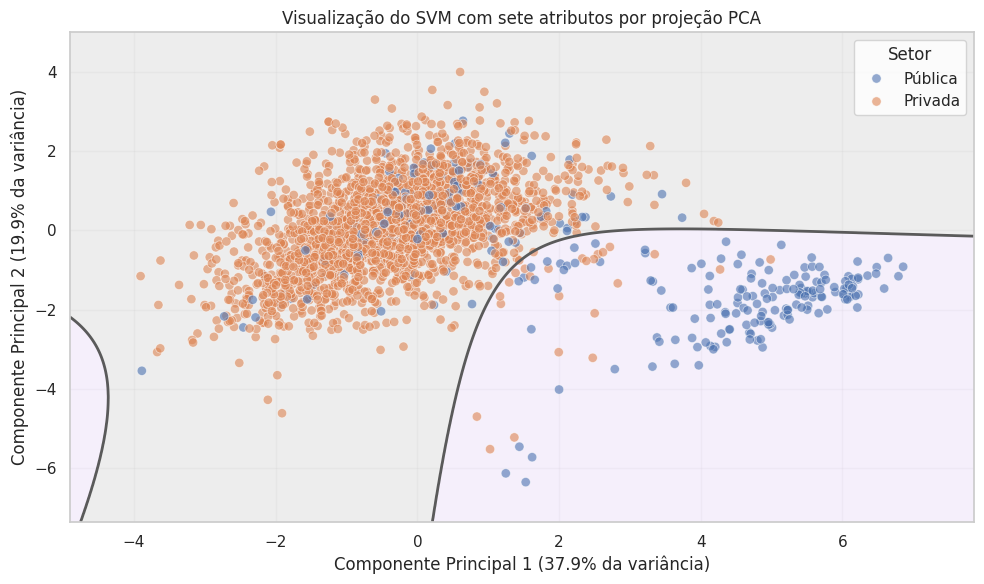

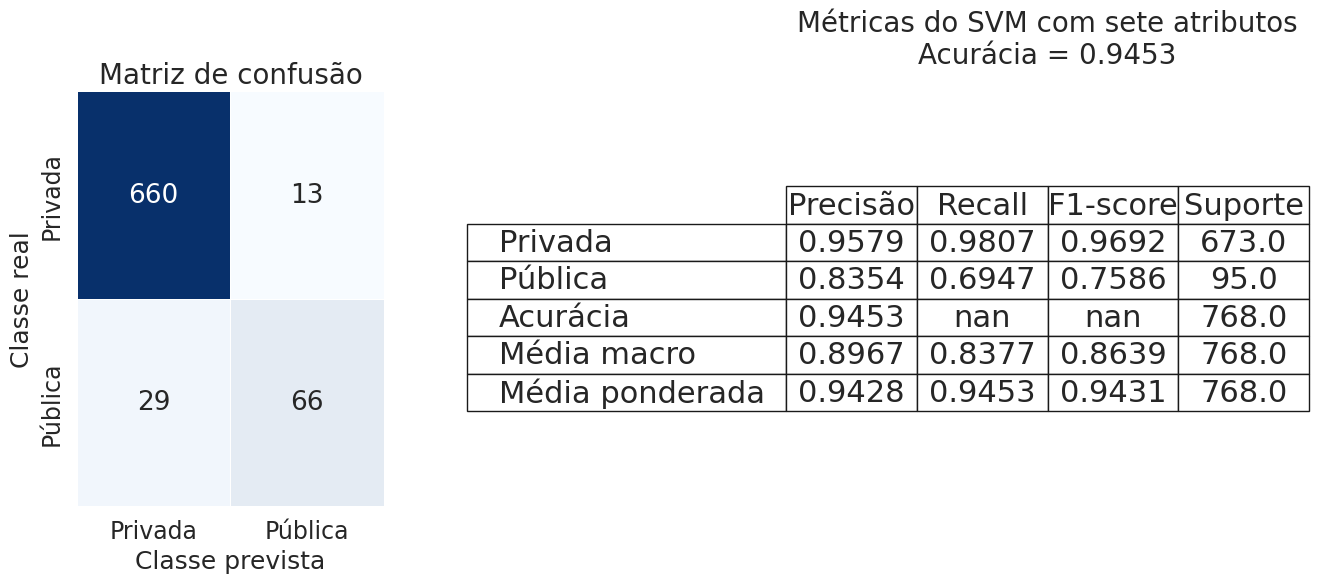

In [ ]:
# ============================================================
# BLOCO 7 - GRÁFICO 8
# SVM Polinomial Grau 3 com 7 atributos
# Métricas do SVM completo + visualização por PCA
# ============================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Atributos derivados
# ------------------------------------------------------------

# Formação stricto sensu
ies["PERC_STRICTO_SENSU"] = ies["PERC_MESTRES"] + ies["PERC_DOUTORES"]

# Regime integral total
ies["PERC_INTEGRAL"] = (ies["QT_DOC_EX_INT"] / ies["QT_DOC_EXE"]) * 100

# Log do total de docentes
ies["LOG_DOC_TOTAL"] = np.log1p(ies["QT_DOC_EXE"])

# Idade média ponderada pelas faixas etárias
midpoints = {
    "QT_DOC_EX_0_29":    25,
    "QT_DOC_EX_30_34":   32,
    "QT_DOC_EX_35_39":   37,
    "QT_DOC_EX_40_44":   42,
    "QT_DOC_EX_45_49":   47,
    "QT_DOC_EX_50_54":   52,
    "QT_DOC_EX_55_59":   57,
    "QT_DOC_EX_60_MAIS": 65,
}

numerador = sum(ies[col] * mid for col, mid in midpoints.items())
denominador = sum(ies[col] for col in midpoints).replace(0, np.nan)

ies["IDADE_MEDIA"] = numerador / denominador

# ------------------------------------------------------------
# Seleção dos 7 atributos
# ------------------------------------------------------------

FEATURES = [
    "PERC_INT_DE",        # % docentes dedicação exclusiva
    "PERC_DOUTORES",      # % docentes doutores
    "PERC_INTEGRAL",      # % docentes em regime integral
    "LOG_DOC_TOTAL",      # porte institucional
    "PERC_PARCIAL",       # % docentes em regime parcial
    "IDADE_MEDIA",        # idade média estimada
    "PERC_STRICTO_SENSU", # % mestres + doutores
]

dados_svm = ies[FEATURES + ["SETOR"]].copy()
dados_svm = dados_svm.replace([np.inf, -np.inf], np.nan).dropna()

X = dados_svm[FEATURES]

y = dados_svm["SETOR"].map({
    "Privada": 0,
    "Pública": 1
})

# ------------------------------------------------------------
# Separação treino/teste
# Importante: split antes da padronização para evitar vazamento
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# Padronização
# O scaler é ajustado apenas no treino
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Também cria a versão padronizada de todos os dados
# apenas para visualização PCA dos pontos no gráfico
X_scaled_all = scaler.transform(X)

# ------------------------------------------------------------
# Class weight baseado no desbalanceamento real do treino
# ------------------------------------------------------------

n_privada = (y_train == 0).sum()
n_publica = (y_train == 1).sum()

ratio = n_privada / n_publica

fator_amplificacao = 1.5

class_weights = {
    0: 1.0,
    1: ratio * fator_amplificacao
}

print("=== DESBALANCEAMENTO DO TREINO ===")
print(f"Privada: {n_privada} | Pública: {n_publica}")
print(f"Razão privada:pública = {ratio:.2f}:1")
print(f"Peso Privada = {class_weights[0]:.2f}")
print(f"Peso Pública = {class_weights[1]:.2f}")

# ------------------------------------------------------------
# Treinamento do SVM com 7 atributos
# ------------------------------------------------------------

THRESHOLD = 0.35

modelo_svm = SVC(
    kernel="poly",
    degree=3,
    C=1.0,
    gamma="scale",
    coef0=1,
    class_weight=class_weights,
    probability=True,
    random_state=42
)

modelo_svm.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Predição e métricas do SVM com 7 atributos
# ------------------------------------------------------------

y_prob = modelo_svm.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

acuracia = accuracy_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)

print("\n=== RESULTADOS DO SVM COM 7 ATRIBUTOS ===")
print(f"Threshold utilizado: {THRESHOLD}")
print(f"Acurácia: {acuracia:.4f}")

print("\nMatriz de confusão:")
print(matriz)

print("\nRelatório de classificação:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Privada", "Pública"]
))

relatorio_dict = classification_report(
    y_test,
    y_pred,
    target_names=["Privada", "Pública"],
    output_dict=True
)

metricas_svm = pd.DataFrame(relatorio_dict).transpose().round(4)

# ------------------------------------------------------------
# PCA para visualização do SVM com 7 atributos
# PCA usado apenas como projeção visual
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)

# Ajusta PCA nos dados de treino padronizados
X_train_pca = pca.fit_transform(X_train_scaled)

# Projeta todos os dados no mesmo espaço PCA
X_pca_all = pca.transform(X_scaled_all)

var_exp = pca.explained_variance_ratio_

print("\n=== VARIÂNCIA EXPLICADA PELO PCA ===")
print(f"Componente Principal 1: {var_exp[0]:.4f} ({var_exp[0]*100:.1f}%)")
print(f"Componente Principal 2: {var_exp[1]:.4f} ({var_exp[1]*100:.1f}%)")
print(f"Variância acumulada: {(var_exp[0] + var_exp[1]):.4f} ({(var_exp[0] + var_exp[1])*100:.1f}%)")

dados_pca = pd.DataFrame({
    "CP1": X_pca_all[:, 0],
    "CP2": X_pca_all[:, 1],
    "SETOR": dados_svm["SETOR"].values
})

# ------------------------------------------------------------
# IMAGEM 1 — Visualização PCA do SVM com 7 atributos
# ------------------------------------------------------------

x_min, x_max = X_pca_all[:, 0].min() - 1, X_pca_all[:, 0].max() + 1
y_min, y_max = X_pca_all[:, 1].min() - 1, X_pca_all[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Malha no espaço PCA
grid_pca = np.c_[xx.ravel(), yy.ravel()]

# Volta da projeção PCA para o espaço padronizado original
# para usar o SVM treinado com os 7 atributos
grid_original_scaled = pca.inverse_transform(grid_pca)

# Predição da malha usando o SVM completo
Z_prob = modelo_svm.predict_proba(grid_original_scaled)[:, 1]
Z = (Z_prob >= THRESHOLD).astype(int).reshape(xx.shape)
Z_prob_matriz = Z_prob.reshape(xx.shape)

plt.figure(figsize=(10, 6))

# Regiões de decisão
plt.contourf(
    xx,
    yy,
    Z,
    levels=[-0.5, 0.5, 1.5],
    colors=["#d8d8d8", "#eadcf8"],
    alpha=0.45
)

# Fronteira de decisão
if Z_prob_matriz.min() <= THRESHOLD <= Z_prob_matriz.max():
    plt.contour(
        xx,
        yy,
        Z_prob_matriz,
        levels=[THRESHOLD],
        colors="#5a5a5a",
        linewidths=2
    )
else:
    print(
        f"Atenção: o threshold {THRESHOLD} não cruza a malha PCA. "
        f"Probabilidades na malha: {Z_prob_matriz.min():.4f} a {Z_prob_matriz.max():.4f}"
    )

# Pontos reais projetados em PCA
sns.scatterplot(
    data=dados_pca,
    x="CP1",
    y="CP2",
    hue="SETOR",
    alpha=0.60,
    s=45
)

plt.xlabel(f"Componente Principal 1 ({var_exp[0]*100:.1f}% da variância)")
plt.ylabel(f"Componente Principal 2 ({var_exp[1]*100:.1f}% da variância)")
plt.title("Visualização do SVM com sete atributos por projeção PCA")
plt.legend(title="Setor")
plt.grid(True, alpha=0.25)
plt.tight_layout()

plt.savefig(
    "grafico_6_svm_7_atributos_pca_2024.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# IMAGEM 2 — Matriz de confusão + tabela de métricas
# Métricas do SVM com 7 atributos
# ------------------------------------------------------------

cor_clara = "#f7fbff"
cor_escura = "#08306b"

cmap_personalizado = LinearSegmentedColormap.from_list(
    "minha_matriz",
    [cor_clara, cor_escura]
)

fig = plt.figure(figsize=(14, 6))

# Matriz de confusão
ax1 = plt.subplot(1, 2, 1)

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap=cmap_personalizado,
    cbar=False,
    xticklabels=["Privada", "Pública"],
    yticklabels=["Privada", "Pública"],
    annot_kws={"size": 19},
    linewidths=0.5,
    linecolor="white",
    ax=ax1
)

ax1.set_xlabel("Classe prevista", fontsize=18)
ax1.set_ylabel("Classe real", fontsize=18)
ax1.set_title("Matriz de confusão", fontsize=20)
ax1.tick_params(axis="both", labelsize=17)

# Tabela de métricas
ax2 = plt.subplot(1, 2, 2)
ax2.axis("off")

tabela_metricas = metricas_svm.loc[
    ["Privada", "Pública", "accuracy", "macro avg", "weighted avg"],
    ["precision", "recall", "f1-score", "support"]
].copy()

if "accuracy" in tabela_metricas.index:
    tabela_metricas.loc["accuracy", "recall"] = np.nan
    tabela_metricas.loc["accuracy", "f1-score"] = np.nan
    tabela_metricas.loc["accuracy", "support"] = len(y_test)

tabela_metricas = tabela_metricas.round(4)

table = ax2.table(
    cellText=tabela_metricas.values,
    rowLabels=["Privada", "Pública", "Acurácia", "Média macro", "Média ponderada"],
    colLabels=["Precisão", "Recall", "F1-score", "Suporte"],
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(22)
table.scale(1.70, 2.5)

ax2.set_title(
    f"Métricas do SVM com sete atributos\nAcurácia = {acuracia:.4f}",
    fontsize=20,
    pad=20
)

plt.tight_layout()

plt.savefig(
    "metricas_svm_7_atributos_2024.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Dimensão da base de cursos: (720349, 10)
Dimensão da base apenas com licenciaturas: (136519, 10)
IES com licenciaturas consideradas: 1133

Avaliação dos valores de k:


,k,Inércia,Silhueta
0,2,5371.5983,0.3194
1,3,4370.7974,0.3692
2,4,3561.9883,0.3753
3,5,3118.7061,0.3324
4,6,2762.5524,0.3371



Coeficiente de silhueta final: 0.3692

Perfil médio dos clusters:


,TX_OCUPACAO_VAGAS,DEMANDA_POR_VAGA,TX_TRANCAMENTO,TX_DESVINCULO,TX_CONCLUSAO,QT_MAT
CLUSTER,,,,,,
0,71.29,2.21,15.48,27.60,13.04,4371.21
1,4.39,0.25,190.01,186.14,68.42,19.01
2,16.46,0.46,23.06,29.62,10.98,489.71



Distribuição dos clusters:
CLUSTER
2    756
0    308
1     69
Name: count, dtype: int64

Cruzamento entre cluster e setor:


SETOR,Privada,Pública
CLUSTER,,
0,165,143
1,67,2
2,704,52



Limite de zoom no eixo X: 204.5
IES fora do zoom: 23


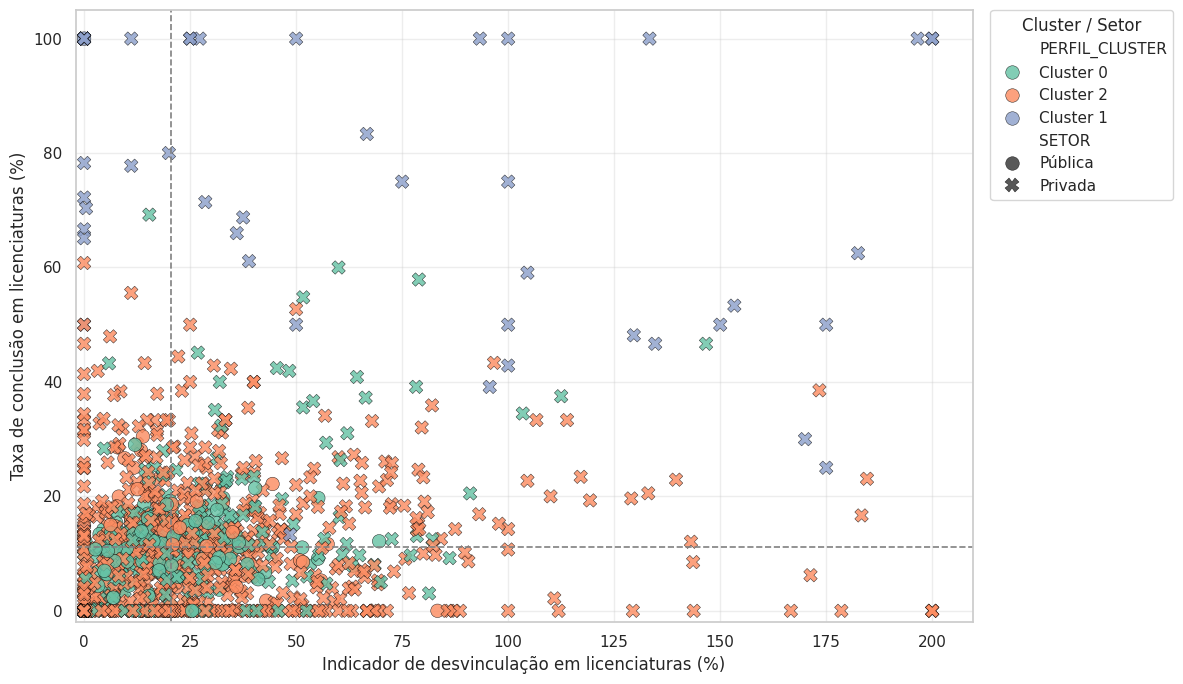

In [ ]:
# ============================================================
# BLOCO 8 - GRÁFICO 9 K-MEANS LICENCIATURAS
# Desvinculação, conclusão e fragilidade na formação docente
# Versão completa com leitura da base de cursos e gráfico melhorado
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ------------------------------------------------------------
# 2. Colunas necessárias da base de cursos
# ------------------------------------------------------------

colunas_cursos = [
    "CO_IES",
    "NO_CURSO",
    "TP_GRAU_ACADEMICO",
    "QT_VG_TOTAL",
    "QT_INSCRITO_TOTAL",
    "QT_ING",
    "QT_MAT",
    "QT_CONC",
    "QT_SIT_TRANCADA",
    "QT_SIT_DESVINCULADO"
]

# ------------------------------------------------------------
# 3. Leitura da base de cursos
# ------------------------------------------------------------

cursos = pd.read_csv(
    caminho_cursos,
    sep=";",
    encoding="latin1",
    usecols=colunas_cursos,
    low_memory=False
)

print("Dimensão da base de cursos:", cursos.shape)

# ------------------------------------------------------------
# 4. Filtra apenas licenciaturas
# TP_GRAU_ACADEMICO = 2 corresponde às licenciaturas
# ------------------------------------------------------------

cursos["TP_GRAU_ACADEMICO"] = pd.to_numeric(
    cursos["TP_GRAU_ACADEMICO"],
    errors="coerce"
)

cursos_lic = cursos[cursos["TP_GRAU_ACADEMICO"] == 2].copy()

print("Dimensão da base apenas com licenciaturas:", cursos_lic.shape)

# ------------------------------------------------------------
# 5. Agrega os dados de licenciatura por IES
# ------------------------------------------------------------

lic_ies = cursos_lic.groupby("CO_IES", as_index=False).agg({
    "QT_VG_TOTAL": "sum",
    "QT_INSCRITO_TOTAL": "sum",
    "QT_ING": "sum",
    "QT_MAT": "sum",
    "QT_CONC": "sum",
    "QT_SIT_TRANCADA": "sum",
    "QT_SIT_DESVINCULADO": "sum"
})

# ------------------------------------------------------------
# 6. Cria indicadores de procura, permanência e conclusão
# ------------------------------------------------------------

lic_ies["TX_OCUPACAO_VAGAS"] = np.where(
    lic_ies["QT_VG_TOTAL"] > 0,
    (lic_ies["QT_ING"] / lic_ies["QT_VG_TOTAL"]) * 100,
    np.nan
)

lic_ies["DEMANDA_POR_VAGA"] = np.where(
    lic_ies["QT_VG_TOTAL"] > 0,
    lic_ies["QT_INSCRITO_TOTAL"] / lic_ies["QT_VG_TOTAL"],
    np.nan
)

lic_ies["TX_TRANCAMENTO"] = np.where(
    lic_ies["QT_MAT"] > 0,
    (lic_ies["QT_SIT_TRANCADA"] / lic_ies["QT_MAT"]) * 100,
    np.nan
)

lic_ies["TX_DESVINCULO"] = np.where(
    lic_ies["QT_MAT"] > 0,
    (lic_ies["QT_SIT_DESVINCULADO"] / lic_ies["QT_MAT"]) * 100,
    np.nan
)

lic_ies["TX_CONCLUSAO"] = np.where(
    lic_ies["QT_MAT"] > 0,
    (lic_ies["QT_CONC"] / lic_ies["QT_MAT"]) * 100,
    np.nan
)

lic_ies["LOG_MAT_LIC"] = np.log1p(lic_ies["QT_MAT"])

# ------------------------------------------------------------
# 7. Cruza com a base de IES já carregada no Bloco 1
# ------------------------------------------------------------

base_lic = lic_ies.merge(
    ies[
        [
            "CO_IES",
            "NO_IES",
            "SG_IES",
            "SETOR",
            "NO_MUNICIPIO_IES",
            "SG_UF_IES"
        ]
    ],
    on="CO_IES",
    how="left"
)

# ------------------------------------------------------------
# 8. Seleciona variáveis para o K-Means
# ------------------------------------------------------------

variaveis_kmeans_lic = [
    "TX_OCUPACAO_VAGAS",
    "DEMANDA_POR_VAGA",
    "TX_TRANCAMENTO",
    "TX_DESVINCULO",
    "TX_CONCLUSAO",
    "LOG_MAT_LIC"
]

dados_kmeans_lic = base_lic[
    [
        "CO_IES",
        "NO_IES",
        "SG_IES",
        "SETOR",
        "NO_MUNICIPIO_IES",
        "SG_UF_IES",
        "QT_MAT"
    ] + variaveis_kmeans_lic
].copy()

dados_kmeans_lic = dados_kmeans_lic.replace([np.inf, -np.inf], np.nan)
dados_kmeans_lic = dados_kmeans_lic.dropna()

# Remove IES sem matrícula em licenciatura
dados_kmeans_lic = dados_kmeans_lic[dados_kmeans_lic["QT_MAT"] > 0].copy()

print("IES com licenciaturas consideradas:", dados_kmeans_lic.shape[0])

# ------------------------------------------------------------
# 9. Padronização dos atributos
# ------------------------------------------------------------

X_lic = dados_kmeans_lic[variaveis_kmeans_lic]

scaler_lic = StandardScaler()
X_lic_scaled = scaler_lic.fit_transform(X_lic)

# ------------------------------------------------------------
# 10. Avalia diferentes valores de k
# ------------------------------------------------------------

avaliacao_k = []

for k in range(2, 7):
    modelo_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_temp = modelo_temp.fit_predict(X_lic_scaled)

    avaliacao_k.append({
        "k": k,
        "Inércia": modelo_temp.inertia_,
        "Silhueta": silhouette_score(X_lic_scaled, labels_temp)
    })

avaliacao_k = pd.DataFrame(avaliacao_k).round(4)

print("\nAvaliação dos valores de k:")
display(avaliacao_k)

# ------------------------------------------------------------
# 11. K-Means final
# k = 3 para separar perfis baixo/intermediário/alto
# ------------------------------------------------------------

k_final = 3

kmeans_lic = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

dados_kmeans_lic["CLUSTER"] = kmeans_lic.fit_predict(X_lic_scaled)

silhueta_final = silhouette_score(
    X_lic_scaled,
    dados_kmeans_lic["CLUSTER"]
)

print("\nCoeficiente de silhueta final:", round(silhueta_final, 4))

# ------------------------------------------------------------
# 12. Perfil médio dos clusters
# ------------------------------------------------------------

perfil_clusters_lic = dados_kmeans_lic.groupby("CLUSTER")[
    [
        "TX_OCUPACAO_VAGAS",
        "DEMANDA_POR_VAGA",
        "TX_TRANCAMENTO",
        "TX_DESVINCULO",
        "TX_CONCLUSAO",
        "QT_MAT"
    ]
].mean().round(2)

print("\nPerfil médio dos clusters:")
display(perfil_clusters_lic)

print("\nDistribuição dos clusters:")
print(dados_kmeans_lic["CLUSTER"].value_counts())

print("\nCruzamento entre cluster e setor:")
display(pd.crosstab(dados_kmeans_lic["CLUSTER"], dados_kmeans_lic["SETOR"]))

# ============================================================
# 13. GRÁFICO MELHORADO COM ZOOM
# ============================================================

# Cria cópia específica para o gráfico
dados_plot = dados_kmeans_lic.copy()

# Limite do eixo X pelo percentil 98
# Isso evita que poucos valores extremos comprimam todos os pontos no canto esquerdo
limite_x = dados_plot["TX_DESVINCULO"].quantile(0.98)

qtd_fora_zoom = (dados_plot["TX_DESVINCULO"] > limite_x).sum()

print("\nLimite de zoom no eixo X:", round(limite_x, 2))
print("IES fora do zoom:", qtd_fora_zoom)

# ------------------------------------------------------------
# 14. Rótulos interpretáveis dos clusters
# Primeiro olhe o perfil médio acima.
# Depois ajuste os nomes abaixo conforme os resultados.
# ------------------------------------------------------------

rotulos_cluster = {
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2"
}

dados_plot["PERFIL_CLUSTER"] = dados_plot["CLUSTER"].map(rotulos_cluster)

# ------------------------------------------------------------
# 15. Linhas de referência
# ------------------------------------------------------------

mediana_desvinculo = dados_plot["TX_DESVINCULO"].median()
mediana_conclusao = dados_plot["TX_CONCLUSAO"].median()

# ------------------------------------------------------------
# 16. Versão limpa do gráfico
# Pontos maiores, borda preta, zoom e sem tamanho por matrícula
# ------------------------------------------------------------

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=dados_plot[dados_plot["TX_DESVINCULO"] <= limite_x],
    x="TX_DESVINCULO",
    y="TX_CONCLUSAO",
    hue="PERFIL_CLUSTER",
    style="SETOR",
    s=95,
    alpha=0.82,
    palette="Set2",
    edgecolor="black",
    linewidth=0.35
)

plt.axvline(
    mediana_desvinculo,
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

plt.axhline(
    mediana_conclusao,
    linestyle="--",
    linewidth=1.2,
    color="gray"
)

#plt.title(
    #"Clusterização das IES com licenciaturas por desvinculação e conclusão",
#    fontsize=14
#)

plt.xlabel("Indicador de desvinculação em licenciaturas (%)", fontsize=12)
plt.ylabel("Taxa de conclusão em licenciaturas (%)", fontsize=12)

plt.xlim(-2, limite_x + 5)
plt.ylim(-2, 105)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, alpha=0.35)

plt.legend(
    title="Cluster / Setor",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

#plt.figtext(
#    0.01,
#    -0.02,
#    f"Nota: gráfico com zoom até o percentil 98 do indicador de desvinculação. "
#    f"{qtd_fora_zoom} IES com valores extremos ficaram fora da área exibida.",
#    ha="left",
#    fontsize=10
#)

plt.tight_layout()

plt.savefig(
    "grafico_kmeans_licenciaturas_2024.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Dimensão da base de cursos: (720349, 10)
Dimensão da base apenas com licenciaturas: (136519, 10)
IES encontradas em Uberlândia: 11


,IES_LABEL,NO_IES,SETOR,QT_DOC_EXE,PERC_DOUTORES,PERC_INT_DE,PERC_HORISTA,QT_MAT,QT_CONC,QT_SIT_TRANCADA,QT_SIT_DESVINCULADO,TOTAL_SITUACOES_LIC,PERC_MATRICULADOS_LIC,PERC_CONCLUINTES_LIC,PERC_TRANCADOS_LIC,PERC_DESVINCULADOS_LIC
0,UFU,UNIVERSIDADE FEDERAL DE UBERLÂNDIA,Pública,1929,91.81,87.61,0.00,2359.0,483.0,173.0,360.0,3375.0,69.90,14.31,5.13,10.67
4,CENTRO UNIVERSITÁRIO UNA DE UBERLÂN...,CENTRO UNIVERSITÁRIO UNA DE UBERLÂNDIA,Privada,47,44.68,0.00,59.57,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
3,FACULDADE ANHANGUERA DE UBERLÂNDIA,FACULDADE ANHANGUERA DE UBERLÂNDIA,Privada,160,41.88,0.00,10.62,19.0,11.0,6.0,15.0,51.0,37.25,21.57,11.76,29.41
6,FATRA,FACULDADE DO TRABALHO,Privada,27,40.74,0.00,3.70,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
1,UNITRI,CENTRO UNIVERSITÁRIO DO TRIÂNGULO,Privada,143,34.97,0.00,23.78,1.0,0.0,0.0,1.0,2.0,50.00,0.00,0.00,50.00
8,FEESU,Faculdade de Educação e Estudos Sociais de Ube...,Privada,9,33.33,0.00,55.56,59.0,8.0,0.0,15.0,82.0,71.95,9.76,0.00,18.29
7,FACDEO,Faculdade Coram Deo,Privada,6,33.33,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
5,FAESSA,Faculdade Uberlandense de Núcleos Integrados d...,Privada,93,24.73,0.00,41.94,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,0.00
9,Faculdade Presidente Antônio Carlos...,Faculdade Presidente Antônio Carlos de Uberlândia,Privada,161,21.74,0.00,58.39,59.0,3.0,3.0,7.0,72.0,81.94,4.17,4.17,9.72
10,FAAL,Faculdade Alcance Ensino Superior EaD,Privada,5,20.00,0.00,0.00,3.0,0.0,0.0,2.0,5.0,60.00,0.00,0.00,40.00


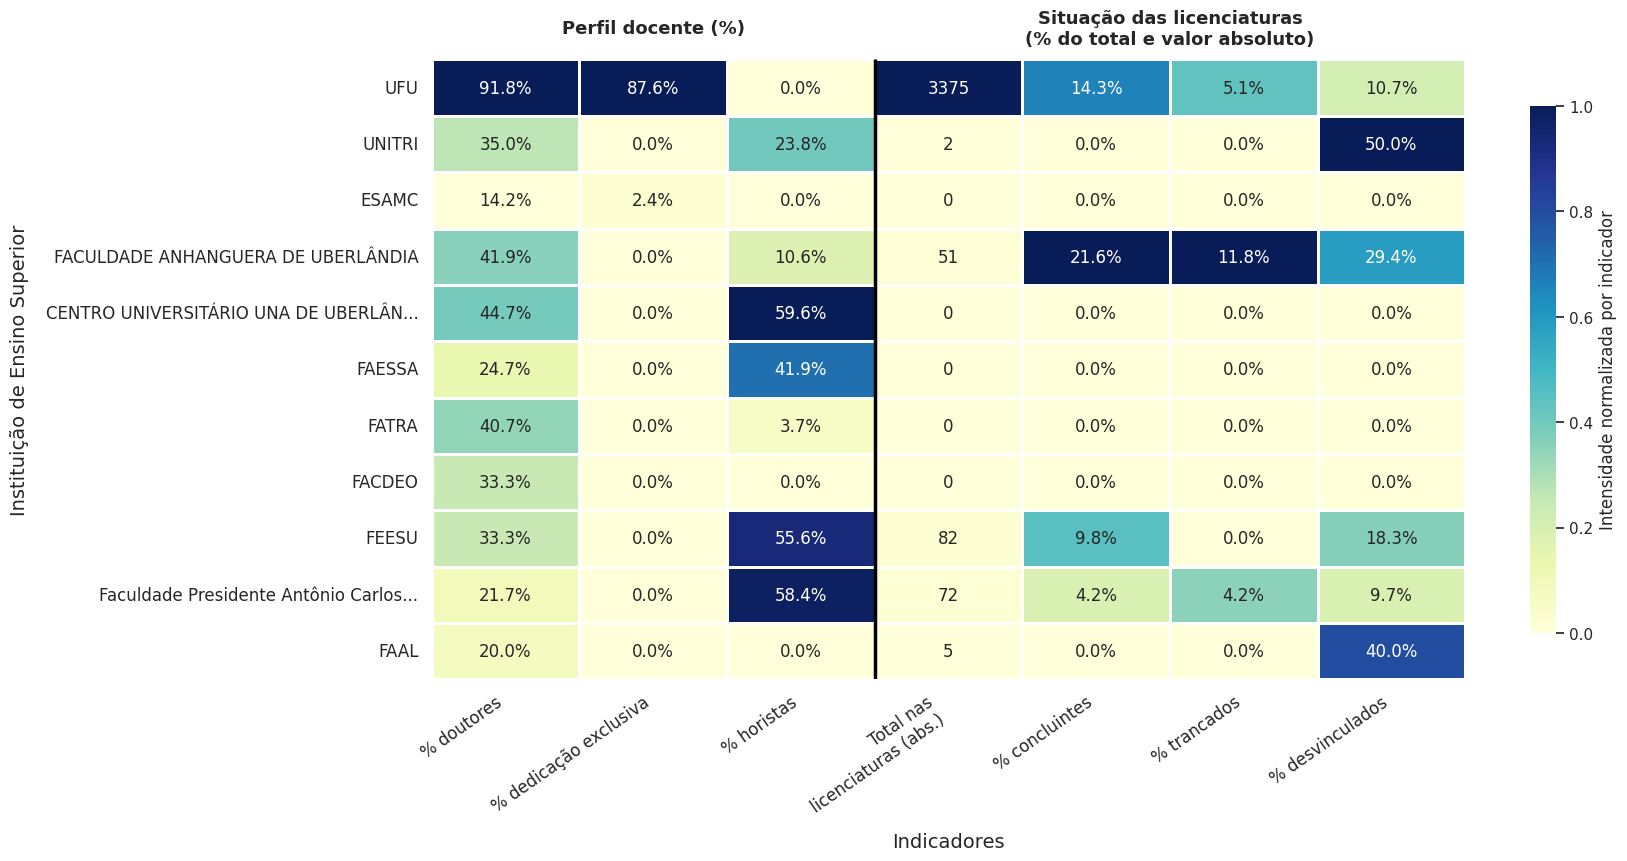

In [ ]:
# ============================================================
# BLOCO 9 - GRÁFICO 10 ESTUDO DE CASO UBERLÂNDIA
# Perfil docente + situação das licenciaturas
# Percentuais corrigidos com base no total de situações
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Leitura da base de cursos
# Usa o caminho já definido no BLOCO 1:
# caminho_cursos = f"{pasta_dados}/MICRODADOS_CADASTRO_CURSOS_2024.CSV"
# ------------------------------------------------------------

colunas_cursos = [
    "CO_IES",
    "NO_CURSO",
    "TP_GRAU_ACADEMICO",
    "QT_VG_TOTAL",
    "QT_INSCRITO_TOTAL",
    "QT_ING",
    "QT_MAT",
    "QT_CONC",
    "QT_SIT_TRANCADA",
    "QT_SIT_DESVINCULADO"
]

cursos = pd.read_csv(
    caminho_cursos,
    sep=";",
    encoding="latin1",
    usecols=colunas_cursos,
    low_memory=False
)

print("Dimensão da base de cursos:", cursos.shape)

# ------------------------------------------------------------
# 2. Filtra apenas licenciaturas
# TP_GRAU_ACADEMICO = 2 corresponde às licenciaturas
# ------------------------------------------------------------

cursos["TP_GRAU_ACADEMICO"] = pd.to_numeric(
    cursos["TP_GRAU_ACADEMICO"],
    errors="coerce"
)

cursos_lic = cursos[cursos["TP_GRAU_ACADEMICO"] == 2].copy()

print("Dimensão da base apenas com licenciaturas:", cursos_lic.shape)

# ------------------------------------------------------------
# 3. Agrega os dados de licenciatura por IES
# ------------------------------------------------------------

lic_ies = cursos_lic.groupby("CO_IES", as_index=False).agg({
    "QT_VG_TOTAL": "sum",
    "QT_INSCRITO_TOTAL": "sum",
    "QT_ING": "sum",
    "QT_MAT": "sum",
    "QT_CONC": "sum",
    "QT_SIT_TRANCADA": "sum",
    "QT_SIT_DESVINCULADO": "sum"
})

# ------------------------------------------------------------
# 4. Total de situações analisadas nas licenciaturas
# Agora os percentuais passam a ter o mesmo denominador
# ------------------------------------------------------------

lic_ies["TOTAL_SITUACOES_LIC"] = (
    lic_ies["QT_MAT"] +
    lic_ies["QT_CONC"] +
    lic_ies["QT_SIT_TRANCADA"] +
    lic_ies["QT_SIT_DESVINCULADO"]
)

# ------------------------------------------------------------
# 5. Indicadores de composição do fluxo das licenciaturas
# Esses percentuais agora são partes de um mesmo total
# ------------------------------------------------------------

lic_ies["PERC_MATRICULADOS_LIC"] = np.where(
    lic_ies["TOTAL_SITUACOES_LIC"] > 0,
    (lic_ies["QT_MAT"] / lic_ies["TOTAL_SITUACOES_LIC"]) * 100,
    0
)

lic_ies["PERC_CONCLUINTES_LIC"] = np.where(
    lic_ies["TOTAL_SITUACOES_LIC"] > 0,
    (lic_ies["QT_CONC"] / lic_ies["TOTAL_SITUACOES_LIC"]) * 100,
    0
)

lic_ies["PERC_TRANCADOS_LIC"] = np.where(
    lic_ies["TOTAL_SITUACOES_LIC"] > 0,
    (lic_ies["QT_SIT_TRANCADA"] / lic_ies["TOTAL_SITUACOES_LIC"]) * 100,
    0
)

lic_ies["PERC_DESVINCULADOS_LIC"] = np.where(
    lic_ies["TOTAL_SITUACOES_LIC"] > 0,
    (lic_ies["QT_SIT_DESVINCULADO"] / lic_ies["TOTAL_SITUACOES_LIC"]) * 100,
    0
)

# Indicadores adicionais, se quiser conferir depois
lic_ies["TX_OCUPACAO_VAGAS_LIC"] = np.where(
    lic_ies["QT_VG_TOTAL"] > 0,
    (lic_ies["QT_ING"] / lic_ies["QT_VG_TOTAL"]) * 100,
    0
)

lic_ies["DEMANDA_POR_VAGA_LIC"] = np.where(
    lic_ies["QT_VG_TOTAL"] > 0,
    lic_ies["QT_INSCRITO_TOTAL"] / lic_ies["QT_VG_TOTAL"],
    0
)

# ------------------------------------------------------------
# 6. Filtra IES localizadas em Uberlândia
# ------------------------------------------------------------

ies_uberlandia = ies[
    ies["NO_MUNICIPIO_IES"].astype(str).str.upper().str.strip() == "UBERLÂNDIA"
].copy()

if ies_uberlandia.empty:
    ies_uberlandia = ies[
        ies["NO_MUNICIPIO_IES"].astype(str).str.upper().str.strip() == "UBERLANDIA"
    ].copy()

print("IES encontradas em Uberlândia:", ies_uberlandia.shape[0])

# ------------------------------------------------------------
# 7. Garante indicadores docentes
# ------------------------------------------------------------

ies_uberlandia["PERC_DOUTORES"] = (
    ies_uberlandia["QT_DOC_EX_DOUT"] / ies_uberlandia["QT_DOC_EXE"]
) * 100

ies_uberlandia["PERC_MESTRES"] = (
    ies_uberlandia["QT_DOC_EX_MEST"] / ies_uberlandia["QT_DOC_EXE"]
) * 100

ies_uberlandia["PERC_STRICTO_SENSU"] = (
    ies_uberlandia["PERC_MESTRES"] + ies_uberlandia["PERC_DOUTORES"]
)

ies_uberlandia["PERC_INT_DE"] = (
    ies_uberlandia["QT_DOC_EX_INT_DE"] / ies_uberlandia["QT_DOC_EXE"]
) * 100

ies_uberlandia["PERC_HORISTA"] = (
    ies_uberlandia["QT_DOC_EX_HOR"] / ies_uberlandia["QT_DOC_EXE"]
) * 100

ies_uberlandia = ies_uberlandia.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 8. Limpeza do nome/sigla da instituição
# ------------------------------------------------------------

ies_uberlandia["SG_IES"] = ies_uberlandia["SG_IES"].astype(str).str.strip()
ies_uberlandia["NO_IES"] = ies_uberlandia["NO_IES"].astype(str).str.strip()

ies_uberlandia["SG_IES"] = ies_uberlandia["SG_IES"].replace(
    ["", "0", "nan", "None", "NONE", "NAN"],
    np.nan
)

ies_uberlandia["IES_LABEL"] = ies_uberlandia["SG_IES"]
ies_uberlandia["IES_LABEL"] = ies_uberlandia["IES_LABEL"].fillna(
    ies_uberlandia["NO_IES"]
)

ies_uberlandia["IES_LABEL"] = ies_uberlandia["IES_LABEL"].apply(
    lambda x: x if len(x) <= 35 else x[:35] + "..."
)

# ------------------------------------------------------------
# 9. Junta IES de Uberlândia com os indicadores das licenciaturas
# ------------------------------------------------------------

base_uberlandia = ies_uberlandia.merge(
    lic_ies[
        [
            "CO_IES",
            "QT_MAT",
            "QT_CONC",
            "QT_SIT_TRANCADA",
            "QT_SIT_DESVINCULADO",
            "TOTAL_SITUACOES_LIC",
            "PERC_MATRICULADOS_LIC",
            "PERC_CONCLUINTES_LIC",
            "PERC_TRANCADOS_LIC",
            "PERC_DESVINCULADOS_LIC"
        ]
    ],
    on="CO_IES",
    how="left"
)

# ------------------------------------------------------------
# 10. IES sem licenciatura recebem zero nos indicadores de curso
# ------------------------------------------------------------

colunas_lic = [
    "QT_MAT",
    "QT_CONC",
    "QT_SIT_TRANCADA",
    "QT_SIT_DESVINCULADO",
    "TOTAL_SITUACOES_LIC",
    "PERC_MATRICULADOS_LIC",
    "PERC_CONCLUINTES_LIC",
    "PERC_TRANCADOS_LIC",
    "PERC_DESVINCULADOS_LIC"
]

base_uberlandia[colunas_lic] = base_uberlandia[colunas_lic].fillna(0)

# ------------------------------------------------------------
# 11. Tabela de conferência
# ------------------------------------------------------------

tabela_uberlandia = base_uberlandia[
    [
        "IES_LABEL",
        "NO_IES",
        "SETOR",
        "QT_DOC_EXE",
        "PERC_DOUTORES",
        "PERC_INT_DE",
        "PERC_HORISTA",
        "QT_MAT",
        "QT_CONC",
        "QT_SIT_TRANCADA",
        "QT_SIT_DESVINCULADO",
        "TOTAL_SITUACOES_LIC",
        "PERC_MATRICULADOS_LIC",
        "PERC_CONCLUINTES_LIC",
        "PERC_TRANCADOS_LIC",
        "PERC_DESVINCULADOS_LIC"
    ]
].copy()

tabela_uberlandia = tabela_uberlandia.sort_values(
    "PERC_DOUTORES",
    ascending=False
)

display(tabela_uberlandia.round(2))

# ============================================================
# 12. MAPA DE CALOR CORRIGIDO
# Agora os percentuais das licenciaturas são partes do mesmo total
# ============================================================

variaveis_heatmap = [
    "PERC_DOUTORES",
    "PERC_INT_DE",
    "PERC_HORISTA",
    "TOTAL_SITUACOES_LIC",
    "PERC_CONCLUINTES_LIC",
    "PERC_TRANCADOS_LIC",
    "PERC_DESVINCULADOS_LIC"
]

dados_heatmap = base_uberlandia[
    ["IES_LABEL"] + variaveis_heatmap
].copy()

dados_heatmap = dados_heatmap.set_index("IES_LABEL")

# ------------------------------------------------------------
# 13. Renomeia colunas de forma mais clara
# ------------------------------------------------------------

dados_heatmap = dados_heatmap.rename(columns={
    "PERC_DOUTORES": "% doutores",
    "PERC_INT_DE": "% dedicação exclusiva",
    "PERC_HORISTA": "% horistas",
    "TOTAL_SITUACOES_LIC": "Total nas\nlicenciaturas (abs.)",
    "PERC_CONCLUINTES_LIC": "% concluintes",
    "PERC_TRANCADOS_LIC": "% trancados",
    "PERC_DESVINCULADOS_LIC": "% desvinculados"
})

# ------------------------------------------------------------
# 14. Anotações: percentuais com %, absolutos como inteiros
# ------------------------------------------------------------

annot_labels = dados_heatmap.copy().astype(object)

colunas_percentuais = [
    "% doutores",
    "% dedicação exclusiva",
    "% horistas",
    "% concluintes",
    "% trancados",
    "% desvinculados"
]

colunas_absolutas = [
    "Total nas\nlicenciaturas (abs.)"
]

for col in colunas_percentuais:
    annot_labels[col] = dados_heatmap[col].apply(lambda x: f"{x:.1f}%")

for col in colunas_absolutas:
    annot_labels[col] = dados_heatmap[col].apply(lambda x: f"{int(round(x, 0))}")

# ------------------------------------------------------------
# 15. Normalização por coluna apenas para as cores
# ------------------------------------------------------------

dados_heatmap_norm = dados_heatmap.copy()

for col in dados_heatmap_norm.columns:
    minimo = dados_heatmap_norm[col].min()
    maximo = dados_heatmap_norm[col].max()

    if maximo > minimo:
        dados_heatmap_norm[col] = (
            (dados_heatmap_norm[col] - minimo) / (maximo - minimo)
        )
    else:
        dados_heatmap_norm[col] = 0

# ------------------------------------------------------------
# 16. Gera o mapa de calor maior
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(19, 10))

sns.heatmap(
    dados_heatmap_norm,
    annot=annot_labels,
    fmt="",
    cmap="YlGnBu",
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "Intensidade normalizada por indicador",
        "shrink": 0.85
    },
    annot_kws={
        "fontsize": 12
    },
    ax=ax
)

#ax.set_title(
#    "Perfil docente e situação das licenciaturas nas IES de Uberlândia - 2024",
#    fontsize=18,
#    pad=45
#)

ax.set_xlabel("Indicadores", fontsize=14, labelpad=12)
ax.set_ylabel("Instituição de Ensino Superior", fontsize=14, labelpad=12)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right",
    fontsize=12
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=12
)

# Linha separando perfil docente e licenciaturas
ax.vlines(
    x=3,
    ymin=0,
    ymax=len(dados_heatmap_norm.index),
    colors="black",
    linewidth=2.5
)

# Rótulos superiores
ax.text(
    1.5,
    -0.55,
    "Perfil docente (%)",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

ax.text(
    5.0,
    -0.55,
    "Situação das licenciaturas\n(% do total e valor absoluto)",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

# Barra de cores
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)
cbar.set_label(
    "Intensidade normalizada por indicador",
    fontsize=12
)

# Nota explicativa
#nota = (
#    "Nota: nas licenciaturas, os percentuais de concluintes, trancados e desvinculados foram calculados sobre o mesmo total: "
#    "matriculados + concluintes + trancados + desvinculados.\n"
#    "Assim, esses indicadores representam partes de uma mesma composição. "
#    "O total das licenciaturas é valor absoluto. As cores foram normalizadas separadamente por coluna."
#)

#fig.text(
#    0.01,
#    0.01,
#    nota,
#    ha="left",
#    va="bottom",
#    fontsize=11
#)

plt.subplots_adjust(
    left=0.22,
    right=0.90,
    top=0.86,
    bottom=0.24
)

plt.savefig(
    "grafico_uberlandia_situacao_licenciaturas_2024.pdf",
    format="pdf",
    bbox_inches="tight"
)


plt.show()